In [1]:
# 1)Import libraries
# Core BigQuery client
from google.cloud import bigquery

# Optional but common companions
import pandas as pd

In [2]:
# 2) Authenticate
# Option 1 — Service account key file (most common in notebooks)
from google.oauth2 import service_account

credentials = service_account.Credentials.from_service_account_file(
    '/home/szemainwong/mainitexp1-856bc2c1e42f.json'
)
client = bigquery.Client(credentials=credentials, project='mainitexp1')

In [3]:
# List all tables in a dataset
dataset_ref = client.dataset("Brazil_ecommerce", project="mainitexp1")
tables = list(client.list_tables(dataset_ref))

for table in tables:
    print(table.table_id)   # prints the exact table name to use

olist_customers_dataset
olist_geolocation_dataset
olist_order_items_dataset
olist_order_payments_dataset
olist_order_reviews_dataset
olist_orders_dataset
olist_products_dataset
olist_sellers_dataset
product_category_name_translation


In [4]:
# List all tables in a dataset
dataset_ref = client.dataset("brazil_ecommerce_proj", project="mainitexp1")
tables = list(client.list_tables(dataset_ref))

for table in tables:
    print(table.table_id)

deduplicate
dim_customers
dim_products
dim_reviews
dim_sellers
fact_orders
stg_customers
stg_geolocation
stg_order_items
stg_order_payments
stg_orders
stg_products
stg_reviews
stg_sellers


In [ ]:
#!!DO NOT RUN THIS CELL!!
!pip install db-dtypes==1.4.3

  Attempting uninstall: db-dtypes
    Found existing installation: db-dtypes 1.6.0
    Uninstalling db-dtypes-1.6.0:
      Successfully uninstalled db-dtypes-1.6.0


In [5]:
import db_dtypes

In [6]:
# 3) Read the tables
# --- Read entire table directly ---
table_ref = client.get_table("mainitexp1.Brazil_ecommerce.olist_customers_dataset") #get_table("your_project.your_dataset.your_table")
df = client.list_rows(table_ref).to_dataframe()
df.head()

/home/szemainwong/miniconda3/envs/elt1/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,2201362e68992f654942dc0067c1b716,f7d7fc0a59ef4363fdce6e3aa069d498,69900,rio branco,AC
1,31dbc13addc753e210692eacaea065e4,5dbba6c01268a8ad43f79157bf4454a0,69900,rio branco,AC
2,dad907e170748a35ef4e92238b7308f3,36b1c0516f123351ffa87430416dcae5,69900,rio branco,AC
3,888d2ebe1af2a8c93c75dae5dfc23719,721d1092e1a6460c67e6a0e691d899a3,69900,rio branco,AC
4,8a0108267d9258a0ec9f74381bc9b0de,7a2dc4682890550ebe3b8befcea3d55c,69900,rio branco,AC


# Setup DONE!
## EDA on mart tables below:

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Biz - Revenue Performance
# Monthly revenue trend with order volume
# --- Read using SQL query ---
query = """
SELECT 
    DATE_TRUNC(order_purchase_timestamp, MONTH) AS month, 
    COUNT(DISTINCT id) AS total_orders, 
    COUNT(DISTINCT customer_id) AS unique_customers, 
    ROUND(SUM(price), 2) AS gross_revenue, 
    ROUND(SUM(freight_value), 2) AS total_freight, 
    ROUND(SUM(price + freight_value), 2) AS total_revenue, 
    ROUND(AVG(price), 2) AS avg_order_value
FROM `mainitexp1.brazil_ecommerce_proj.fact_orders`
WHERE order_status = 'delivered' AND 
    order_purchase_timestamp IS NOT NULL
GROUP BY 1
ORDER BY 1
"""
df_query = client.query(query).to_dataframe()
#df_query.head()


/home/szemainwong/miniconda3/envs/elt1/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


/home/szemainwong/miniconda3/envs/elt1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/szemainwong/miniconda3/envs/elt1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


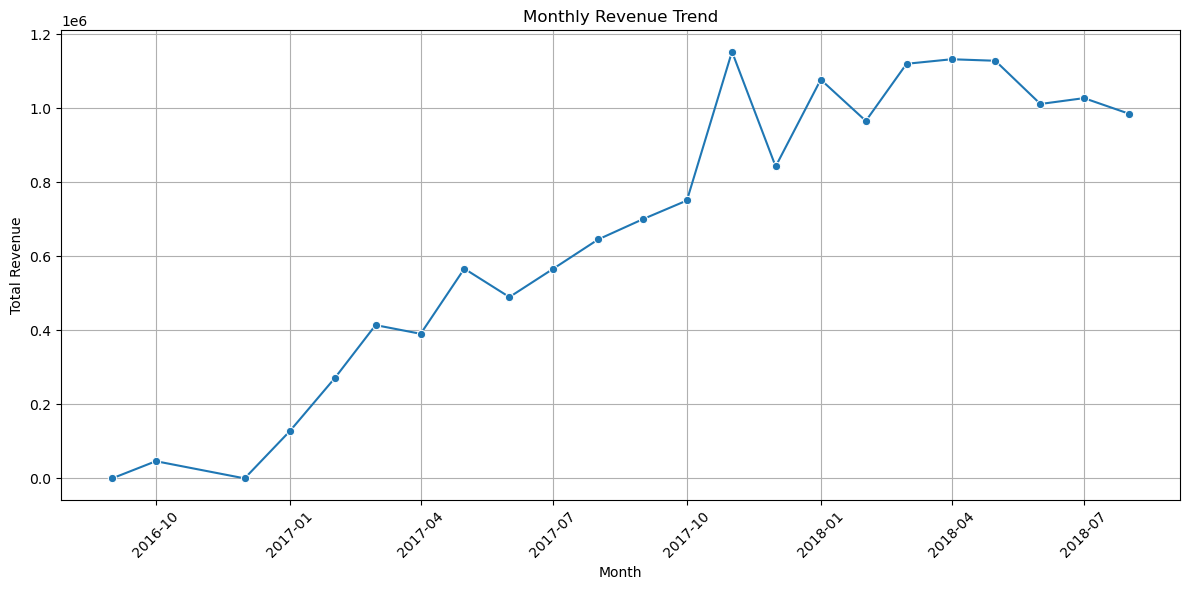

In [8]:
#plot the monthly revenue trend
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_query, x='month', y='total_revenue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [9]:
# Biz - Seller Performance Ranking
# Top sellers by revenue with delivery quality
# --- Read using SQL query ---
query = """
SELECT 
    s.id AS seller_id, 
    s.seller_state, 
    s.seller_city, 
    COUNT(DISTINCT f.id) AS total_orders, 
    ROUND(SUM(f.price), 2) AS total_revenue, 
    ROUND(AVG(f.price), 2) AS avg_order_value, 
    ROUND(AVG(r.review_score), 2) AS avg_review_score, 
    COUNTIF(f.is_long_delivery) AS long_delivery_count, 
    COUNTIF(f.has_invalid_delivery_date) AS invalid_delivery_count 
FROM `mainitexp1.brazil_ecommerce_proj.fact_orders` f
LEFT JOIN `mainitexp1.brazil_ecommerce_proj.dim_sellers` s ON f.seller_id = s.id 
LEFT JOIN `mainitexp1.brazil_ecommerce_proj.dim_reviews` r ON f.id = r.order_id 
WHERE f.order_status = 'delivered' 
GROUP BY 1, 2, 3 
ORDER BY total_revenue DESC
"""
df_query = client.query(query).to_dataframe()


/home/szemainwong/miniconda3/envs/elt1/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


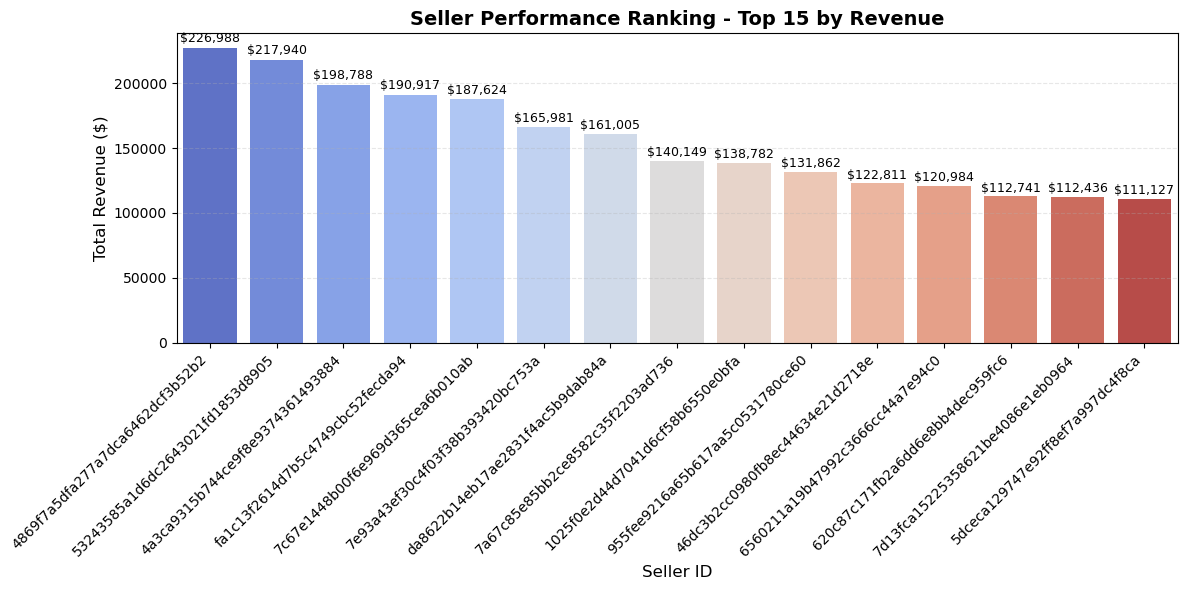

In [11]:
# plot Seller Performance Ranking
plt.figure(figsize=(12, 6))
df_sorted = df_query.sort_values('total_revenue', ascending=False).head(15)

ax = sns.barplot(data=df_sorted, x='seller_id', y='total_revenue', palette='coolwarm')

# Add value labels on bars
for i, v in enumerate(df_sorted['total_revenue']):
    ax.text(i, v + (v*0.01), f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.title('Seller Performance Ranking - Top 15 by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Seller ID', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

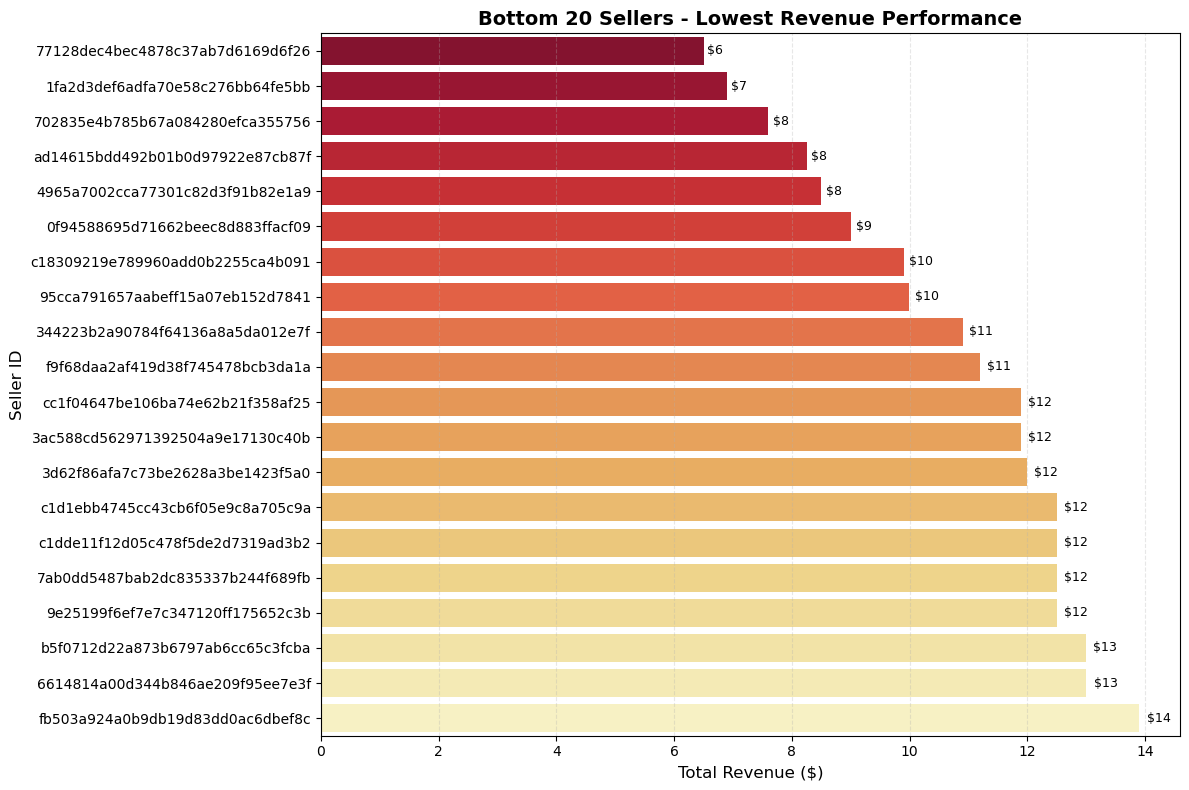

In [12]:
#plot on bottom 20 sellers
plt.figure(figsize=(12, 8))
df_bottom20 = df_query.sort_values('total_revenue', ascending=True).head(20)

ax = sns.barplot(data=df_bottom20, x='total_revenue', y='seller_id', palette='YlOrRd_r')

# Add value labels at the end of each bar
for i, v in enumerate(df_bottom20['total_revenue']):
    ax.text(v + (v*0.01) if v > 0 else v + 1, i, f'${v:,.0f}', 
            va='center', ha='left', fontsize=9)

plt.title('Bottom 20 Sellers - Lowest Revenue Performance', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Seller ID', fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

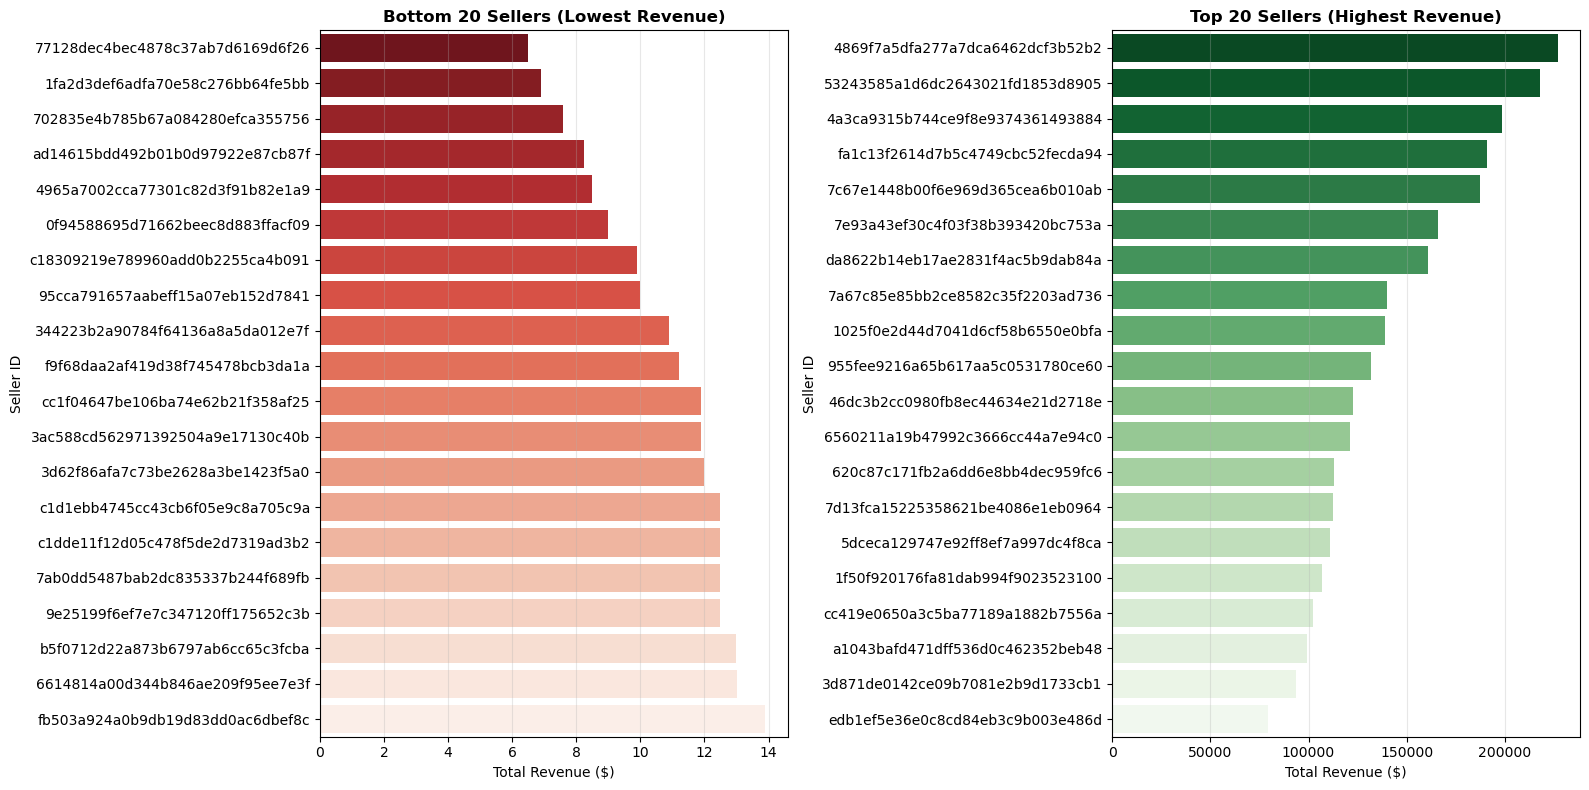

In [13]:
#Bottom 20 vs Top 20
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bottom 20
df_bottom20 = df_query.sort_values('total_revenue', ascending=True).head(20)
sns.barplot(ax=axes[0], data=df_bottom20, x='total_revenue', y='seller_id', palette='Reds_r')
axes[0].set_title('Bottom 20 Sellers (Lowest Revenue)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].set_ylabel('Seller ID')
axes[0].grid(axis='x', alpha=0.3)

# Top 20
df_top20 = df_query.sort_values('total_revenue', ascending=False).head(20)
sns.barplot(ax=axes[1], data=df_top20, x='total_revenue', y='seller_id', palette='Greens_r')
axes[1].set_title('Top 20 Sellers (Highest Revenue)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].set_ylabel('Seller ID')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
#Biz - Product Category Performance
# Revenue and review score by Product Category
# --- Read using SQL query ---
query = """
SELECT 
    p.product_category, 
    COUNT(DISTINCT f.id) AS total_orders, 
    ROUND(SUM(f.price), 2) AS total_revenue, 
    ROUND(AVG(f.price), 2) AS avg_price, 
    ROUND(AVG(f.freight_value), 2) AS avg_freight, 
    ROUND(AVG(r.review_score), 2) AS avg_review_score, 
    COUNTIF(f.is_long_delivery) AS long_deliveries, -- Freight as % of price (logistics efficiency) 
    ROUND(AVG(f.freight_value / NULLIF(f.price, 0)) * 100, 2) AS freight_pct_of_price 
FROM `mainitexp1.brazil_ecommerce_proj.fact_orders` f 
LEFT JOIN `mainitexp1.brazil_ecommerce_proj.dim_products` p ON f.product_id = p.id 
LEFT JOIN `mainitexp1.brazil_ecommerce_proj.dim_reviews` r ON f.id = r.order_id 
WHERE f.order_status = 'delivered'
GROUP BY 1 
ORDER BY total_revenue DESC
"""
df_query = client.query(query).to_dataframe()

/home/szemainwong/miniconda3/envs/elt1/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


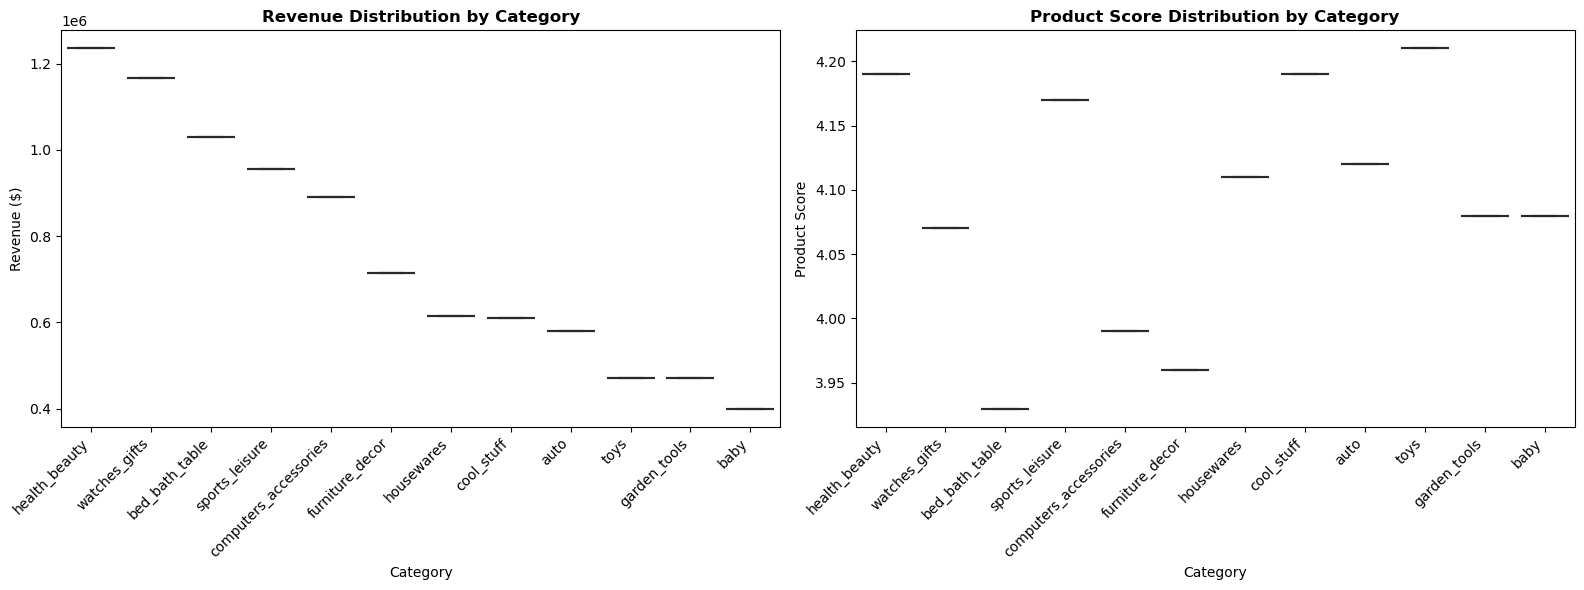

In [14]:
#plot 
# Get top 12 categories by revenue
top_categories = df_query.groupby('product_category')['total_revenue'].sum().nlargest(12).index
df_top = df_query[df_query['product_category'].isin(top_categories)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue distribution
sns.boxplot(ax=axes[0], data=df_top, x='product_category', y='total_revenue', palette='viridis')
axes[0].set_title('Revenue Distribution by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=10)
axes[0].set_ylabel('Revenue ($)', fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Product score distribution
sns.boxplot(ax=axes[1], data=df_top, x='product_category', y='avg_review_score', palette='viridis')
axes[1].set_title('Product Score Distribution by Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Category', fontsize=10)
axes[1].set_ylabel('Product Score', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()